# Notebook 03 — ML Baseline : Prédiction de la consommation énergétique SWRO

**PFE — Master Science des Données**

## Objectif

Construire et comparer plusieurs modèles de régression pour prédire :

`SEC_kWh_m3`

à partir des 8 variables de fonctionnement sélectionnées dans le Notebook 02.

### Modèles
1. Linear Regression
2. Ridge Regression
3. Random Forest Regressor
4. Gradient Boosting Regressor
5. MLP Regressor

### Métriques
- MAE
- RMSE
- R²
- temps d'entraînement

**Important :** les modèles utilisent uniquement les variables d'entrée disponibles avant le calcul de la SEC afin d'éviter la fuite d'information.

In [1]:
# ============================================================
# 0. IMPORTS ET CONFIGURATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import time

from pathlib import Path

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

RANDOM_STATE = 42

DATA_DIR = Path("data/preprocessed")
MODEL_DIR = Path("models")
RESULT_DIR = Path("results")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration chargée.")

Configuration chargée.


## 1. Chargement des données prétraitées

In [2]:
X_train = pd.read_csv(DATA_DIR / "X_train_scaled.csv")
X_val = pd.read_csv(DATA_DIR / "X_val_scaled.csv")
X_test = pd.read_csv(DATA_DIR / "X_test_scaled.csv")

y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze("columns")
y_val = pd.read_csv(DATA_DIR / "y_val.csv").squeeze("columns")
y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze("columns")

print("X_train :", X_train.shape)
print("X_val   :", X_val.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_val   :", y_val.shape)
print("y_test  :", y_test.shape)

display(X_train.head())

X_train : (7000, 8)
X_val   : (1500, 8)
X_test  : (1500, 8)
y_train : (7000,)
y_val   : (1500,)
y_test  : (1500,)


,pressure_bar,feed_flow_m3_h,salinity_g_L,temperature_C,recovery_rate_target,pump_efficiency,erd_efficiency,membrane_condition
0,-1.252086,-1.334266,1.195971,-1.507221,-0.230595,-0.592079,0.884568,1.385462
1,-0.607163,-0.402370,0.976080,-1.126818,-0.663239,0.244659,1.021106,0.805274
2,0.599831,-0.591445,-0.190194,-0.689525,0.433609,0.779581,0.213395,-1.269585
3,0.188196,1.054957,-1.421044,1.060113,-0.343479,0.021215,0.902775,-0.897845
4,0.228027,-0.926895,0.047152,0.607454,-1.252969,-0.029387,0.311307,-0.457171


## 2. Vérification des features

Le modèle doit utiliser exactement les 8 variables définies dans le Notebook 02.

In [3]:
expected_features = [
    "pressure_bar",
    "feed_flow_m3_h",
    "salinity_g_L",
    "temperature_C",
    "recovery_rate_target",
    "pump_efficiency",
    "erd_efficiency",
    "membrane_condition",
]

assert list(X_train.columns) == expected_features

print("Features validées :")
for feature in X_train.columns:
    print("✓", feature)

Features validées :
✓ pressure_bar
✓ feed_flow_m3_h
✓ salinity_g_L
✓ temperature_C
✓ recovery_rate_target
✓ pump_efficiency
✓ erd_efficiency
✓ membrane_condition


## 3. Vérification de la cible

In [4]:
print("Statistiques de y_train :")
display(y_train.describe())

print("\nStatistiques de y_test :")
display(y_test.describe())

assert y_train.notna().all()
assert y_test.notna().all()
assert (y_train > 0).all()
assert (y_test > 0).all()

print("Cible validée.")

Statistiques de y_train :


count    7000.000000
mean        3.617006
std         0.510629
min         2.315995
25%         3.248347
50%         3.567067
75%         3.938607
max         5.540228
Name: SEC_kWh_m3, dtype: float64


Statistiques de y_test :


count    1500.000000
mean        3.627768
std         0.522331
min         2.458759
25%         3.236457
50%         3.589958
75%         3.963861
max         5.631305
Name: SEC_kWh_m3, dtype: float64

Cible validée.


## 4. Définition des modèles

Les hyperparamètres utilisés ici constituent une **baseline**, pas encore une optimisation exhaustive.

In [5]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge": Ridge(
        alpha=1.0
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        min_samples_split=2,
        min_samples_leaf=2,
        random_state=RANDOM_STATE
    ),

    "MLP": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30,
        random_state=RANDOM_STATE
    )
}

print("Modèles :", ", ".join(models.keys()))

Modèles : Linear Regression, Ridge, Random Forest, Gradient Boosting, MLP


## 5. Fonction d'évaluation

Les métriques sont calculées sur validation pendant le développement.

\[
MAE = \frac{1}{n}\sum |y_i-\hat y_i|
\]

\[
RMSE = \sqrt{\frac{1}{n}\sum(y_i-\hat y_i)^2}
\]

\[
R^2 = 1-\frac{SS_{res}}{SS_{tot}}
\]

In [6]:
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

## 6. Entraînement des modèles

Le test final n'est **pas utilisé** ici pour choisir le meilleur modèle.

In [7]:
validation_results = []
trained_models = {}

for name, model in models.items():

    print(f"Entraînement : {name}")

    start = time.perf_counter()

    model.fit(X_train, y_train)

    elapsed = time.perf_counter() - start

    y_pred_val = model.predict(X_val)

    mae, rmse, r2 = evaluate_regression(
        y_val,
        y_pred_val
    )

    validation_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Training_Time_s": elapsed
    })

    trained_models[name] = model

validation_results_df = (
    pd.DataFrame(validation_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(validation_results_df)

Entraînement : Linear Regression
Entraînement : Ridge
Entraînement : Random Forest
Entraînement : Gradient Boosting
Entraînement : MLP


,Model,MAE,RMSE,R2,Training_Time_s
0,MLP,0.092146,0.115368,0.947117,2.078984
1,Gradient Boosting,0.090459,0.115681,0.946830,3.206523
2,Random Forest,0.098033,0.123790,0.939114,1.589234
3,Ridge,0.098946,0.126795,0.936122,0.004977
4,Linear Regression,0.098953,0.126801,0.936116,0.012747


## 7. Comparaison graphique sur validation

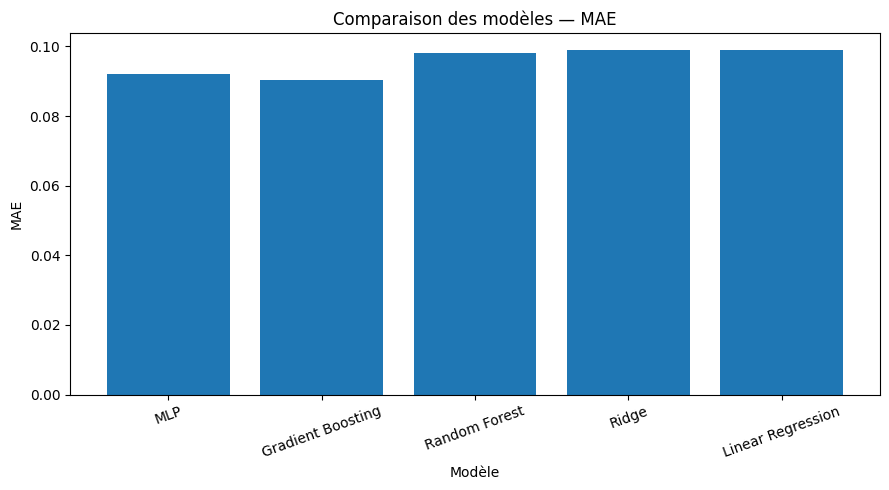

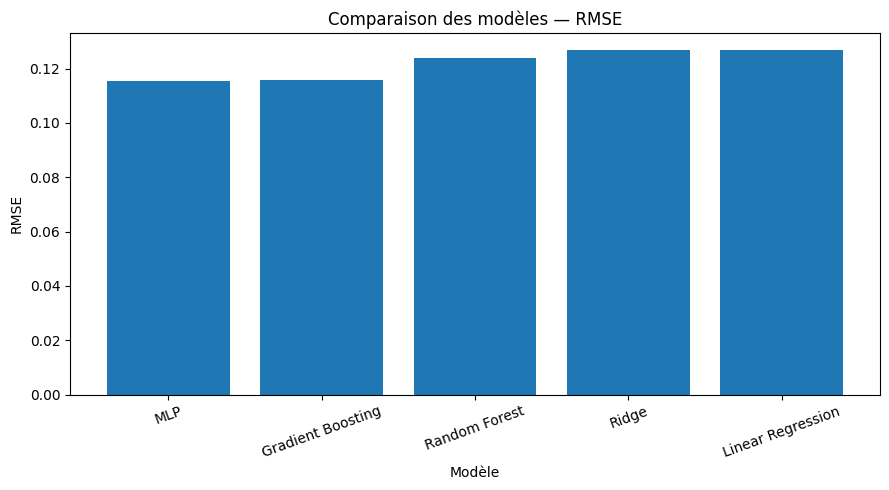

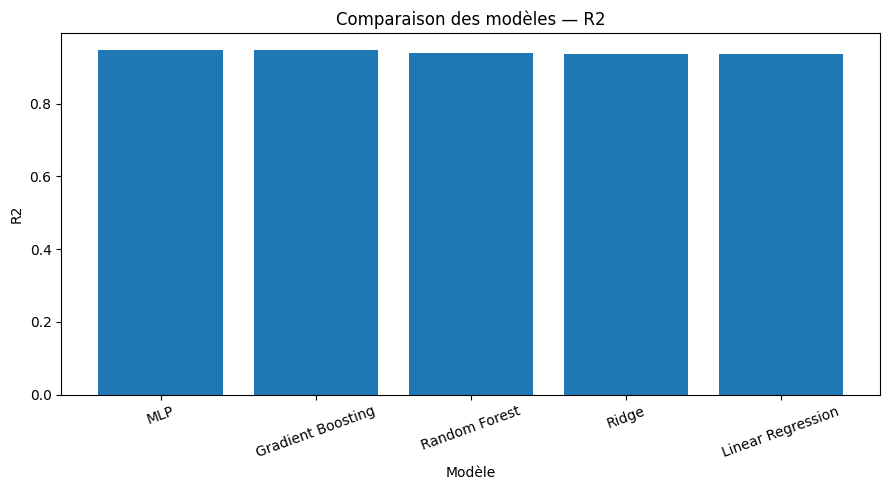

In [8]:
metrics_to_plot = ["MAE", "RMSE", "R2"]

for metric in metrics_to_plot:
    plt.figure(figsize=(9, 5))
    plt.bar(
        validation_results_df["Model"],
        validation_results_df[metric]
    )
    plt.ylabel(metric)
    plt.xlabel("Modèle")
    plt.title(f"Comparaison des modèles — {metric}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

## 8. Sélection du meilleur modèle

Pour une tâche de régression, nous retenons d'abord le modèle avec le **RMSE de validation le plus faible**.

In [9]:
best_model_name = validation_results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Meilleur modèle selon le RMSE de validation :")
print(best_model_name)

display(
    validation_results_df[
        validation_results_df["Model"] == best_model_name
    ]
)

Meilleur modèle selon le RMSE de validation :
MLP


,Model,MAE,RMSE,R2,Training_Time_s
0,MLP,0.092146,0.115368,0.947117,2.078984


## 9. Évaluation finale sur le test

Le jeu de test est utilisé **une seule fois** pour obtenir l'estimation finale des performances du modèle sélectionné.

In [10]:
y_pred_test = best_model.predict(X_test)

test_mae, test_rmse, test_r2 = evaluate_regression(
    y_test,
    y_pred_test
)

test_results = pd.DataFrame([{
    "Model": best_model_name,
    "MAE": test_mae,
    "RMSE": test_rmse,
    "R2": test_r2
}])

display(test_results)

print(f"MAE  : {test_mae:.6f} kWh/m³")
print(f"RMSE : {test_rmse:.6f} kWh/m³")
print(f"R²   : {test_r2:.6f}")

,Model,MAE,RMSE,R2
0,MLP,0.090223,0.114807,0.951657


MAE  : 0.090223 kWh/m³
RMSE : 0.114807 kWh/m³
R²   : 0.951657


## 10. Valeurs réelles vs prédictions

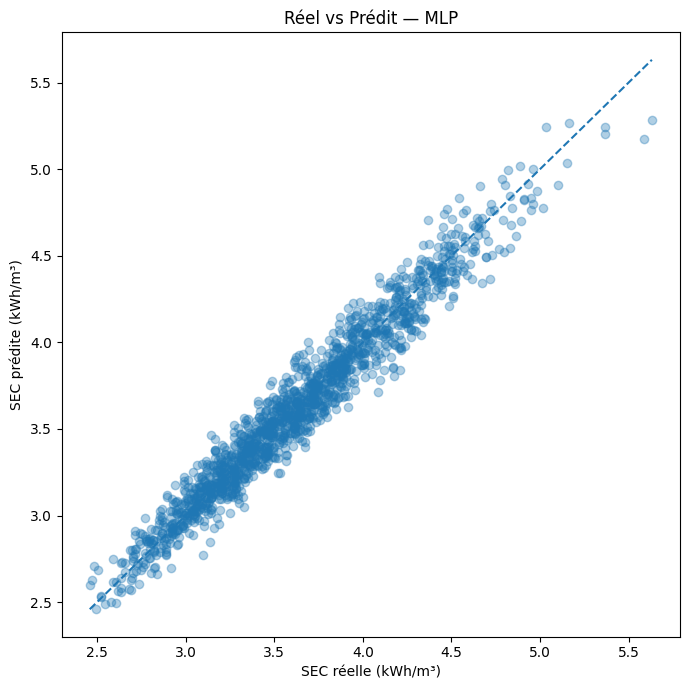

In [11]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, alpha=0.35)

minimum = min(y_test.min(), y_pred_test.min())
maximum = max(y_test.max(), y_pred_test.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("SEC réelle (kWh/m³)")
plt.ylabel("SEC prédite (kWh/m³)")
plt.title(f"Réel vs Prédit — {best_model_name}")
plt.tight_layout()
plt.show()

## 11. Analyse des résidus

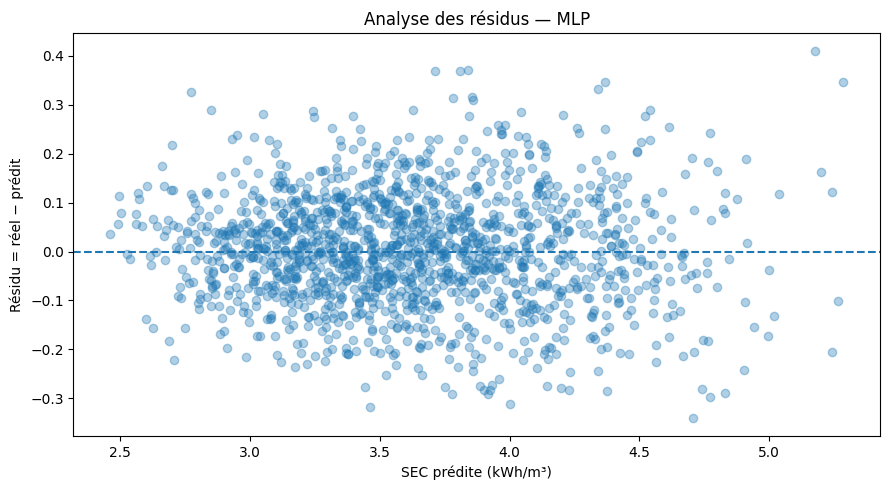

Moyenne des résidus : 0.003863939702769925
Écart-type des résidus : 0.11474221353946158


In [12]:
residuals = y_test.values - y_pred_test

plt.figure(figsize=(9, 5))
plt.scatter(y_pred_test, residuals, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("SEC prédite (kWh/m³)")
plt.ylabel("Résidu = réel − prédit")
plt.title(f"Analyse des résidus — {best_model_name}")
plt.tight_layout()
plt.show()

print("Moyenne des résidus :", residuals.mean())
print("Écart-type des résidus :", residuals.std())

## 12. Importance des variables — Random Forest

Cette analyse est indépendante du choix final du meilleur modèle et permet de comprendre quelles variables sont les plus utilisées par le Random Forest.

,Feature,Importance
0,pump_efficiency,0.354613
1,recovery_rate_target,0.321777
2,pressure_bar,0.251954
3,erd_efficiency,0.048463
4,temperature_C,0.005900
5,feed_flow_m3_h,0.005890
6,salinity_g_L,0.005759
7,membrane_condition,0.005645


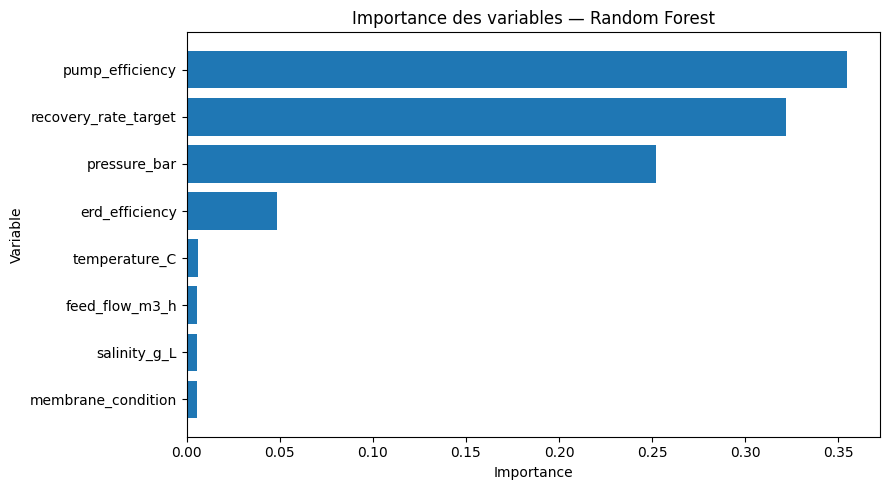

In [13]:
rf_model = trained_models["Random Forest"]

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(rf_importance)

plt.figure(figsize=(9, 5))
plt.barh(
    rf_importance["Feature"][::-1],
    rf_importance["Importance"][::-1]
)
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Importance des variables — Random Forest")
plt.tight_layout()
plt.show()

## 13. Coefficients de Linear Regression

Les coefficients donnent une première indication de la direction de l'effet après standardisation.

,Feature,Coefficient
0,pressure_bar,0.252842
2,salinity_g_L,0.002324
1,feed_flow_m3_h,0.001780
3,temperature_C,0.000643
7,membrane_condition,0.000361
6,erd_efficiency,-0.108642
4,recovery_rate_target,-0.281552
5,pump_efficiency,-0.299209


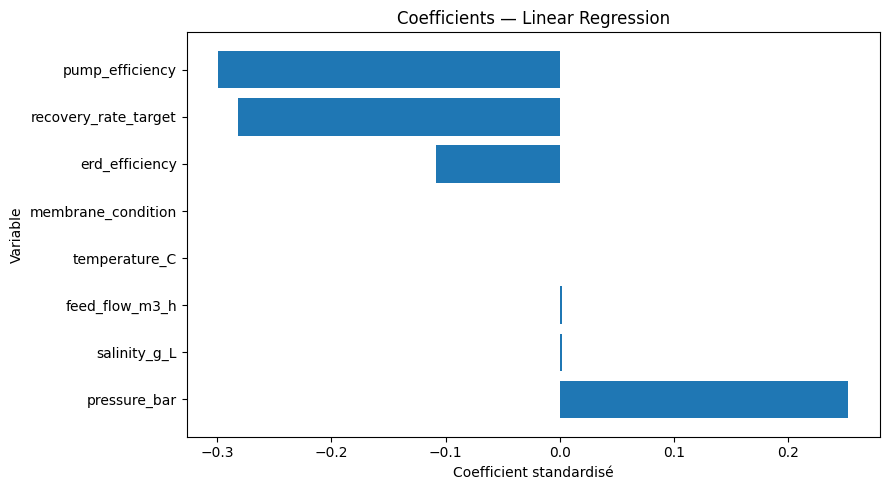

In [14]:
linear_model = trained_models["Linear Regression"]

linear_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": linear_model.coef_
}).sort_values(
    "Coefficient",
    ascending=False
)

display(linear_coefficients)

plt.figure(figsize=(9, 5))
plt.barh(
    linear_coefficients["Feature"],
    linear_coefficients["Coefficient"]
)
plt.xlabel("Coefficient standardisé")
plt.ylabel("Variable")
plt.title("Coefficients — Linear Regression")
plt.tight_layout()
plt.show()

## 14. Validation croisée optionnelle du meilleur modèle

Cette étape sert à vérifier que la performance de validation n'est pas due à un split particulier.

In [15]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_rmse_scores = np.sqrt(
    -cross_val_score(
        best_model,
        X_train,
        y_train,
        scoring="neg_mean_squared_error",
        cv=kf,
        n_jobs=-1
    )
)

print("RMSE CV :", cv_rmse_scores)
print(f"RMSE CV moyen : {cv_rmse_scores.mean():.6f}")
print(f"RMSE CV écart-type : {cv_rmse_scores.std():.6f}")

RMSE CV : [0.11464547 0.11691232 0.11503147 0.11371486 0.1148465 ]
RMSE CV moyen : 0.115030
RMSE CV écart-type : 0.001044


## 15. Sauvegarde des résultats

In [16]:
validation_results_df.to_csv(
    RESULT_DIR / "baseline_validation_results.csv",
    index=False
)

test_results.to_csv(
    RESULT_DIR / "best_model_test_results.csv",
    index=False
)

rf_importance.to_csv(
    RESULT_DIR / "random_forest_feature_importance.csv",
    index=False
)

linear_coefficients.to_csv(
    RESULT_DIR / "linear_regression_coefficients.csv",
    index=False
)

predictions_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred_test,
    "residual": residuals
})

predictions_df.to_csv(
    RESULT_DIR / "test_predictions.csv",
    index=False
)

model_path = MODEL_DIR / "best_model_baseline.pkl"
joblib.dump(best_model, model_path)

print("Résultats sauvegardés dans :", RESULT_DIR.resolve())
print("Modèle sauvegardé :", model_path.resolve())

Résultats sauvegardés dans : C:\Users\UltraPc\Documents\pfe\code\results
Modèle sauvegardé : C:\Users\UltraPc\Documents\pfe\code\models\best_model_baseline.pkl


# Conclusion du Notebook 03

À la fin de l'exécution, le tableau de validation permet de sélectionner le meilleur modèle.

Le rapport doit présenter :

1. le modèle baseline le plus performant ;
2. MAE, RMSE et R² sur validation ;
3. MAE, RMSE et R² sur le test final ;
4. la comparaison réel/prédit ;
5. l'analyse des résidus ;
6. l'importance des variables ;
7. la stabilité par validation croisée.

### Étape suivante

**Notebook 04 — Optimisation des hyperparamètres**

Nous optimiserons le meilleur modèle avec une recherche systématique des hyperparamètres, puis nous comparerons :

`Baseline → Optimisé → Test final`.

Les performances finales ne devront être annoncées qu'après cette étape.